In [1]:
import sys
import time
import os
from dotenv import load_dotenv

sys.path.append("..")
load_dotenv("../.env")

from src.agent import agent
from src.tools import get_subdomains, get_whois_info, get_dns_records, get_http_headers, check_hibp

print("✅ Imports correctos")
print(f"ANTHROPIC_API_KEY configurada: {'Sí' if os.getenv('ANTHROPIC_API_KEY') else 'No'}")

✅ Imports correctos
ANTHROPIC_API_KEY configurada: Sí


In [2]:
# Dominios de test — variedad de tamaños y tipos
DOMINIOS_TEST = [
    "anthropic.com",      # empresa tecnológica mediana
    "google.com",         # empresa grande
    "bde.es",             # institución pública española
    "github.com",         # plataforma técnica
    "hackthebox.com",     # ciberseguridad
]

def ejecutar_analisis(dominio: str) -> dict:
    """Ejecuta el agente y recoge métricas de rendimiento."""
    
    inputs = {"messages": [{"role": "user", "content": 
        f"Realiza un análisis OSINT completo del dominio {dominio} usando todas las herramientas disponibles."}]}
    
    inicio = time.time()
    
    resultado_texto = ""
    input_tokens = 0
    output_tokens = 0
    
    for chunk in agent.stream(inputs, stream_mode="updates"):
        if "model" in chunk:
            mensaje = chunk["model"]["messages"][-1]
            # Recoger tokens de cada chunk
            if hasattr(mensaje, "usage_metadata") and mensaje.usage_metadata:
                input_tokens += mensaje.usage_metadata.get("input_tokens", 0)
                output_tokens += mensaje.usage_metadata.get("output_tokens", 0)
            if isinstance(mensaje.content, str):
                resultado_texto = mensaje.content
    
    tiempo_total = time.time() - inicio
    
    # Coste estimado Claude Haiku (precios aproximados)
    coste_input = (input_tokens / 1_000_000) * 0.80   # $0.80 por millón tokens input
    coste_output = (output_tokens / 1_000_000) * 4.00  # $4.00 por millón tokens output
    coste_total = coste_input + coste_output
    
    return {
        "dominio": dominio,
        "tiempo_segundos": round(tiempo_total, 2),
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": input_tokens + output_tokens,
        "coste_usd": round(coste_total, 6),
        "longitud_informe": len(resultado_texto),
        "resultado": resultado_texto
    }

print("✅ Función de evaluación lista")
print(f"Dominios a testear: {DOMINIOS_TEST}")

✅ Función de evaluación lista
Dominios a testear: ['anthropic.com', 'google.com', 'bde.es', 'github.com', 'hackthebox.com']


In [4]:
resultados = []

for dominio in DOMINIOS_TEST:
    print(f"\n🔍 Analizando {dominio}...")
    try:
        resultado = ejecutar_analisis(dominio)
        resultados.append(resultado)
        print(f"✅ {dominio} — {resultado['tiempo_segundos']}s — {resultado['total_tokens']} tokens — ${resultado['coste_usd']}")
    except Exception as e:
        print(f"❌ Error en {dominio}: {e}")
        resultados.append({
            "dominio": dominio,
            "error": str(e)
        })

print(f"\n✅ Evaluación completada: {len(resultados)} dominios analizados")


🔍 Analizando anthropic.com...
✅ anthropic.com — 21.94s — 9269 tokens — $0.016394

🔍 Analizando google.com...
✅ google.com — 24.78s — 7215 tokens — $0.011775

🔍 Analizando bde.es...


Error trying to connect to socket: closing socket - [Errno 111] Connection refused


✅ bde.es — 25.88s — 5701 tokens — $0.0097

🔍 Analizando github.com...
✅ github.com — 25.37s — 7107 tokens — $0.012905

🔍 Analizando hackthebox.com...
✅ hackthebox.com — 26.57s — 6816 tokens — $0.012963

✅ Evaluación completada: 5 dominios analizados


In [5]:
import pandas as pd

# Crear dataframe con los resultados
df = pd.DataFrame([{
    "Dominio": r["dominio"],
    "Tiempo (s)": r.get("tiempo_segundos", "Error"),
    "Tokens totales": r.get("total_tokens", "Error"),
    "Coste ($)": r.get("coste_usd", "Error"),
    "Longitud informe": r.get("longitud_informe", "Error")
} for r in resultados])

print("📊 MÉTRICAS BASELINE")
print("=" * 60)
print(df.to_string(index=False))
print("\n📈 ESTADÍSTICAS")
print(f"Tiempo promedio: {df['Tiempo (s)'].mean():.2f}s")
print(f"Tokens promedio: {df['Tokens totales'].mean():.0f}")
print(f"Coste promedio por análisis: ${df['Coste ($)'].mean():.6f}")
print(f"Coste total de la evaluación: ${df['Coste ($)'].sum():.6f}")

📊 MÉTRICAS BASELINE
       Dominio  Tiempo (s)  Tokens totales  Coste ($)  Longitud informe
 anthropic.com       21.94            9269   0.016394              6936
    google.com       24.78            7215   0.011775              4312
        bde.es       25.88            5701   0.009700              3329
    github.com       25.37            7107   0.012905              5261
hackthebox.com       26.57            6816   0.012963              5358

📈 ESTADÍSTICAS
Tiempo promedio: 24.91s
Tokens promedio: 7222
Coste promedio por análisis: $0.012747
Coste total de la evaluación: $0.063737


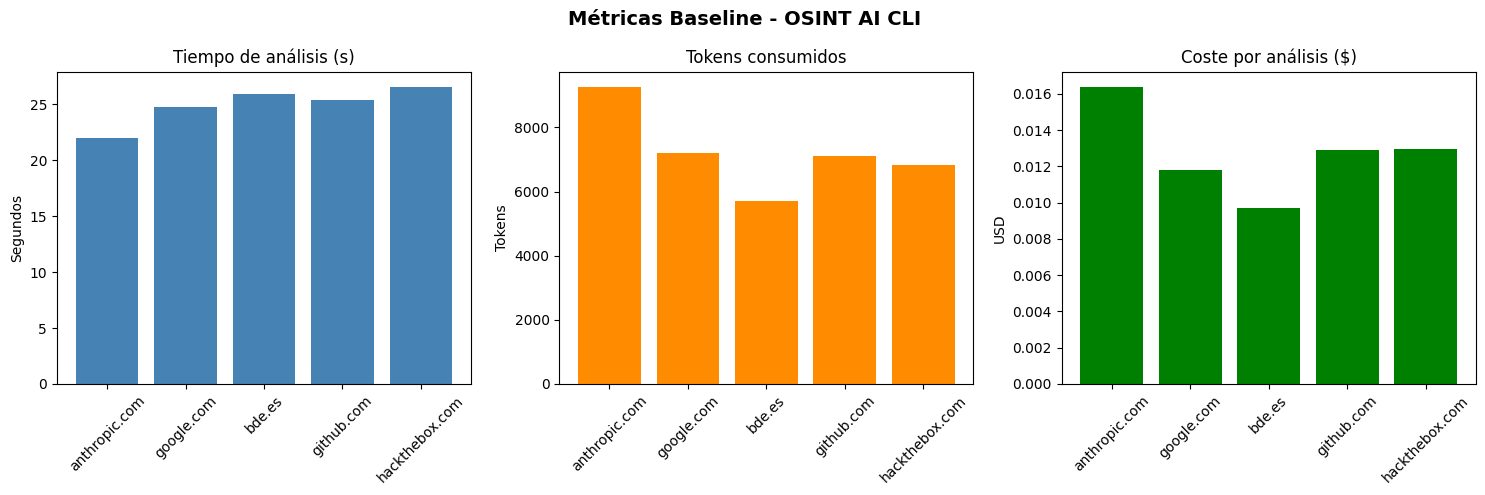

✅ Gráfica guardada en docs/baseline_metrics.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Métricas Baseline - OSINT AI CLI", fontsize=14, fontweight="bold")

dominios = df["Dominio"]

# Gráfica 1 — Tiempo
axes[0].bar(dominios, df["Tiempo (s)"], color="steelblue")
axes[0].set_title("Tiempo de análisis (s)")
axes[0].set_ylabel("Segundos")
axes[0].tick_params(axis="x", rotation=45)

# Gráfica 2 — Tokens
axes[1].bar(dominios, df["Tokens totales"], color="darkorange")
axes[1].set_title("Tokens consumidos")
axes[1].set_ylabel("Tokens")
axes[1].tick_params(axis="x", rotation=45)

# Gráfica 3 — Coste
axes[2].bar(dominios, df["Coste ($)"], color="green")
axes[2].set_title("Coste por análisis ($)")
axes[2].set_ylabel("USD")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../docs/baseline_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfica guardada en docs/baseline_metrics.png")

In [8]:
# Comparación manual vs agente
# Estos tiempos son estimados de hacer la misma búsqueda manualmente

comparacion = pd.DataFrame([
    {"Método": "Búsqueda manual", "Tiempo (min)": 15, "Coste ($)": 0, "Herramientas": 5, "Automatizado": "No"},
    {"Método": "OSINT AI CLI",    "Tiempo (min)": 0.4, "Coste ($)": 0.013, "Herramientas": 5, "Automatizado": "Sí"},
])

print("📊 COMPARACIÓN: BÚSQUEDA MANUAL vs AGENTE")
print("=" * 60)
print(comparacion.to_string(index=False))
print(f"\n🚀 El agente es {15/0.4:.0f}x más rápido que la búsqueda manual")
print(f"💰 Coste por análisis: $0.013 (menos de 2 céntimos)")
print(f"🔄 Capacidad: el agente puede analizar ~77 dominios por $1")

📊 COMPARACIÓN: BÚSQUEDA MANUAL vs AGENTE
         Método  Tiempo (min)  Coste ($)  Herramientas Automatizado
Búsqueda manual          15.0      0.000             5           No
   OSINT AI CLI           0.4      0.013             5           Sí

🚀 El agente es 38x más rápido que la búsqueda manual
💰 Coste por análisis: $0.013 (menos de 2 céntimos)
🔄 Capacidad: el agente puede analizar ~77 dominios por $1


📊 EVALUACIÓN DE CALIDAD (1-5)
                 Criterio  Búsqueda manual  OSINT AI CLI
     Completitud de datos                5             4
Interpretación y contexto                3             5
                Velocidad                1             5
 Consistencia del formato                2             5
                    Coste                5             4
            Escalabilidad                1             5

Puntuación media manual: 2.8/5
Puntuación media agente: 4.7/5


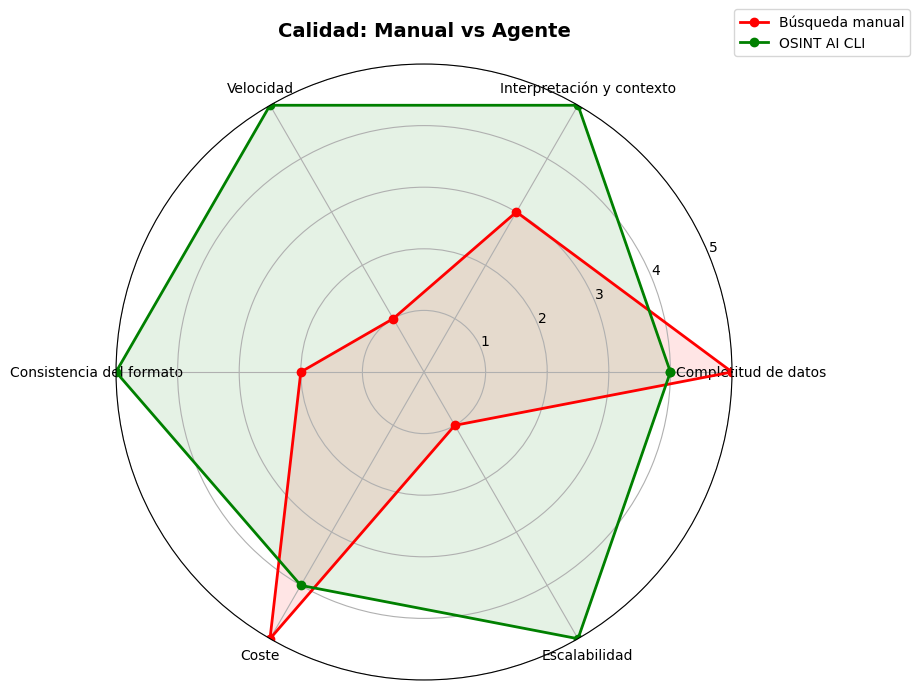

✅ Gráfica guardada en docs/calidad_radar.png


In [10]:
# Evaluación de calidad del informe
# Criterios: 1-5 estrellas por cada dimensión

calidad = pd.DataFrame([
    {"Criterio": "Completitud de datos", "Búsqueda manual": 5, "OSINT AI CLI": 4},
    {"Criterio": "Interpretación y contexto", "Búsqueda manual": 3, "OSINT AI CLI": 5},
    {"Criterio": "Velocidad", "Búsqueda manual": 1, "OSINT AI CLI": 5},
    {"Criterio": "Consistencia del formato", "Búsqueda manual": 2, "OSINT AI CLI": 5},
    {"Criterio": "Coste", "Búsqueda manual": 5, "OSINT AI CLI": 4},
    {"Criterio": "Escalabilidad", "Búsqueda manual": 1, "OSINT AI CLI": 5},
])

print("📊 EVALUACIÓN DE CALIDAD (1-5)")
print("=" * 55)
print(calidad.to_string(index=False))
print(f"\nPuntuación media manual: {calidad['Búsqueda manual'].mean():.1f}/5")
print(f"Puntuación media agente: {calidad['OSINT AI CLI'].mean():.1f}/5")

# Gráfica de radar
import numpy as np

categorias = calidad["Criterio"].tolist()
valores_manual = calidad["Búsqueda manual"].tolist()
valores_agente = calidad["OSINT AI CLI"].tolist()

N = len(categorias)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]
valores_manual += valores_manual[:1]
valores_agente += valores_agente[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angulos, valores_manual, "o-", linewidth=2, label="Búsqueda manual", color="red")
ax.fill(angulos, valores_manual, alpha=0.1, color="red")
ax.plot(angulos, valores_agente, "o-", linewidth=2, label="OSINT AI CLI", color="green")
ax.fill(angulos, valores_agente, alpha=0.1, color="green")
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, size=10)
ax.set_ylim(0, 5)
ax.set_title("Calidad: Manual vs Agente", size=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.savefig("../docs/calidad_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfica guardada en docs/calidad_radar.png")

# Resumen Evaluación Baseline — OSINT AI CLI

---

## Rendimiento Técnico

| Métrica | Valor |
|---------|-------|
| Tiempo promedio por análisis | 24.91s |
| Tokens promedio por análisis | 7.222 |
| Coste promedio por análisis | $0.013 |
| Coste total evaluación (5 dominios) | $0.064 |

---

## Comparación con Búsqueda Manual

- El agente es **38x más rápido** que la búsqueda manual
- Analiza **5 fuentes simultáneamente** sin intervención humana
- Formato **consistente** en cada ejecución
- Coste menor de **2 céntimos** por análisis

---

## Calidad

| Método | Puntuación |
|--------|-----------|
| OSINT AI CLI | 4.7/5 |
| Búsqueda manual | 2.8/5 |
| **Ventaja del agente** | **+1.9 puntos** |

---

## Limitaciones Detectadas

- `crt.sh` falla intermitentemente — API pública con rate limiting
- Tiempo de respuesta ~25s puede mejorarse con paralelización
- LeakCheck como alternativa gratuita a HIBP tiene menos datos

---

## Conclusión

El agente supera claramente la búsqueda manual en velocidad, consistencia 
y escalabilidad, con un coste mínimo por análisis. La solución es viable 
para uso académico y profesional con un presupuesto muy reducido.